# Phase 2 — Baselines (Models A, B, C)

Establishes the three reference points every later claim is measured against:

| ID | Model | Question it answers |
|---|---|---|
| **A** | `clinical_only` | How much biomarker signal is in BCVA + CST alone? |
| **B** | `oct_only` | What can the OCT image do by itself? |
| **C** | `concat_fusion` | Does ordinary feature concatenation add anything to B? |

Model D (gated fusion) is Phase 3 — it is only worth building if C shows fusion has *something*
to work with, or if C fails in a way gating would plausibly fix.

### Ground rules enforced by the code, not by discipline

- One fixed split for all three arms. Comparing across different partitions is meaningless.
- Clinical imputation, scaling and class weights fit on the **training partition only**.
- Thresholds tuned on **validation**, then frozen before test is touched.
- Test is evaluated **once per run**, at the end.

---
## 1. Setup

In [1]:
%cd /content/ClinBioGate
%pip install -U pip setuptools wheel
%pip install -e .

[Errno 2] No such file or directory: '/content/ClinBioGate'
/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 60.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cu128 requires setuptools<82, but you have setuptools 84.0.0 which is incompatible.


Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [3]:
%pip install numpy

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 2.7 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/12.6 MB 2.2 MB/s eta 0:00:06
   ---- ----------------------------------- 1.6/12.6 MB 2.4 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/12.6 MB 2.4 MB/s eta 0:00:05
   -------- ------------------------------- 2.6/12.6 MB 2.4 MB/s eta 0:00:05
   --------- ------------------------------ 3.1/12.6 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 3.7/12.6 MB 2.5 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.6 MB 2.4 MB/s eta 0:00:04
   -------------- ------------------------- 4.7/12.6 MB 2.5 MB/s eta 0:00:04
   ---------------- ----------------------- 5.2/12.6 MB 2.4 MB/s eta 0:00:04
   ------------------ --------------------- 5.8/12.6 MB 2.4 MB/s eta 0:00:03
   ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
%pip install -e

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\Users\BLESS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip 
install [options] <requirement specifier> [package-index-options] ...
  c:\Users\BLESS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip 
install [options] -r <requirements file> [package-index-options] ...
  c:\Users\BLESS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip 
install [options] [-e] <vcs project url> ...
  c:\Users\BLESS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip 
install [options] [-e] <local project path> ...
  c:\Users\BLESS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip 
install [options] <archive url/path> ...

-e option requires 1 argument


In [4]:
from pathlib import Path
import sys
import subprocess

REPO_ROOT = Path("/content/ClinBioGate")

if not (REPO_ROOT / "pyproject.toml").exists():
    subprocess.run(
        ["git", "clone", "https://github.com/PasBless1/ClinBioGate.git",
         str(REPO_ROOT)],
        check=True,
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", str(REPO_ROOT)],
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-e', '/content/ClinBioGate'], returncode=0)

In [6]:
from pathlib import Path
import sys
import importlib

REPO_ROOT = Path("/content/ClinBioGate")
PACKAGE_FILE = REPO_ROOT / "src" / "olives_biomarkers" / "__init__.py"

print("Python:", sys.executable)
print("Repository exists:", REPO_ROOT.exists())
print("Package exists:", PACKAGE_FILE.exists())
print("Expected package:", PACKAGE_FILE)

assert PACKAGE_FILE.exists(), (
    "The repository is missing from /content/ClinBioGate. "
    "Clone it again before continuing."
)

SRC_DIR = str(REPO_ROOT / "src")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

importlib.invalidate_caches()

import olives_biomarkers
print("Imported from:", olives_biomarkers.__file__)

Python: /usr/bin/python3
Repository exists: True
Package exists: True
Expected package: /content/ClinBioGate/src/olives_biomarkers/__init__.py
Imported from: /content/ClinBioGate/src/olives_biomarkers/__init__.py


In [7]:
from olives_biomarkers import (
    OlivesPipeline,
    ExperimentSuite,
    ResultsAggregator,
)

In [8]:
# %load_ext autoreload
# %autoreload 2

import sys, warnings, time
from pathlib import Path

REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
sys.path.insert(0, str(REPO_ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from olives_biomarkers import OlivesPipeline, ExperimentSuite, ResultsAggregator
from olives_biomarkers.config import ConfigLoader
from olives_biomarkers.evaluation import ResultsPlotter

print("repo root:", REPO_ROOT)

repo root: /content


### Choosing a training budget

`configs/local_cpu.yaml` and `configs/colab_gpu.yaml` set the same knobs at different scales.
The local profile exists so the pipeline can be exercised without a GPU — it is a **plumbing
check, not the headline experiment**, and will understate every model.

Anything that goes in the report should come from the GPU profile.

In [10]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path("/content/ClinBioGate").resolve()

assert (REPO_ROOT / "configs" / "data.yaml").exists(), (
    f"Missing configuration: {REPO_ROOT / 'configs' / 'data.yaml'}"
)

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

print("Repository:", REPO_ROOT)
print("Working directory:", Path.cwd())

Repository: /content/ClinBioGate
Working directory: /content/ClinBioGate


In [11]:
from olives_biomarkers import OlivesPipeline

pipeline = OlivesPipeline.from_config(
    REPO_ROOT / "configs" / "data.yaml",
    repo_root=REPO_ROOT,
)

BUDGET = "colab_gpu" if pipeline.env.device == "cuda" else "local_cpu"

print("Device:", pipeline.env.device)
print("Budget profile:", BUDGET)

Device: cuda
Budget profile: colab_gpu


In [12]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [13]:
pipeline = OlivesPipeline.from_config(REPO_ROOT / "configs" / "data.yaml", repo_root=REPO_ROOT)

# Pick automatically: GPU present -> full budget, otherwise the reduced one.
BUDGET = "colab_gpu" if pipeline.env.device == "cuda" else "local_cpu"
print(f"device: {pipeline.env.device}  ->  budget profile: {BUDGET}")

loader = ConfigLoader(REPO_ROOT)
budget = loader.load(REPO_ROOT / "configs" / f"{BUDGET}.yaml")
print(f"  image_size = {budget.data.image_size}")
print(f"  epochs     = {budget.training.epochs}")
print(f"  batch_size = {budget.training.batch_size}")
if BUDGET == "local_cpu":
    print("\n  NOTE: reduced budget. Treat these numbers as a pipeline check, not a result.")

device: cuda  ->  budget profile: colab_gpu
  image_size = (224, 224)
  epochs     = 50
  batch_size = 32


In [14]:
RUNS_DIR = REPO_ROOT / "outputs" / "runs" / BUDGET
FIGURES = REPO_ROOT / "outputs" / "figures" / "phase2"
FIGURES.mkdir(parents=True, exist_ok=True)
plotter = ResultsPlotter()

def show(figure, name):
    """Display a figure and persist it under outputs/figures/phase2."""
    if figure is None:
        print(f"(no figure for {name})")
        return
    plotter.save(figure, FIGURES / f"{name}.png")
    plt.show()

---
## 2. Data and split

The image cache turns training from a 30 GB parquet scan into 9,396 PNG reads. Export it once;
this is also the folder to upload to Drive for Colab.

In [16]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/olives/data/raw/OLIVES")
DISEASE_DIR = DATA_ROOT / "disease_classification"

shards = sorted(DISEASE_DIR.glob("*.parquet"))

print("Dataset root:", DATA_ROOT)
print("Directory exists:", DISEASE_DIR.exists())
print("Parquet shards found:", len(shards))
print("First shard:", shards[0] if shards else "None")

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/olives/data/raw/OLIVES
Directory exists: True
Parquet shards found: 32
First shard: /content/drive/MyDrive/olives/data/raw/OLIVES/disease_classification/train-00000-of-00032.parquet


In [17]:
manifest = pipeline.get_manifest()

# One-off: export the modelling subset as PNGs (~2.3 GB). Skipped if already present.
if not pipeline.image_cache_dir.exists():
    pipeline.export_image_cache(manifest)

frame = pipeline.modelling_frame(manifest, attach_cache=True)
print(f"modelling rows: {len(frame):,}  |  patients: {frame.patient_id.nunique()}")
print(f"labels: {len(manifest.label_columns)}  ({pipeline.config.data.target_set})")
print(f"image cache: {pipeline.image_cache_dir}")

09:42:31 | INFO    | olives.manifest | Building manifest: config=disease_classification split=train shards=32 hashes=True
09:42:43 | INFO    | olives.manifest |   shard  1/32 train-00000-of-00032.parquet     rows=2464
09:42:49 | INFO    | olives.manifest |   shard  2/32 train-00001-of-00032.parquet     rows=2464
09:42:58 | INFO    | olives.manifest |   shard  3/32 train-00002-of-00032.parquet     rows=2464
09:43:05 | INFO    | olives.manifest |   shard  4/32 train-00003-of-00032.parquet     rows=2464
09:43:12 | INFO    | olives.manifest |   shard  5/32 train-00004-of-00032.parquet     rows=2464
09:43:19 | INFO    | olives.manifest |   shard  6/32 train-00005-of-00032.parquet     rows=2464
09:43:26 | INFO    | olives.manifest |   shard  7/32 train-00006-of-00032.parquet     rows=2463
09:43:32 | INFO    | olives.manifest |   shard  8/32 train-00007-of-00032.parquet     rows=2463
09:43:40 | INFO    | olives.manifest |   shard  9/32 train-00008-of-00032.parquet     rows=2463
09:43:47 | INF

In [18]:
assignment = pipeline.make_holdout_split(manifest, write=True)

split_table = pd.DataFrame(
    {
        "partition": list(assignment.partitions),
        "n_patients": [len(v) for v in assignment.partitions.values()],
        "n_scans": [
            int(frame.patient_id.isin(v).sum()) for v in assignment.partitions.values()
        ],
    }
)
split_table

09:46:39 | INFO    | olives.splits | holdout split 'holdout': train=52 val=13 test=13 calibration=9 patients
09:46:39 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits


,partition,n_patients,n_scans
0,train,52,5672
1,val,13,1470
2,test,13,1372
3,calibration,9,882


The `calibration` partition is carved out of *train* and is patient-disjoint from everything
else, so Phase 4's temperature scaling never sees data that fitted the model weights.

---
## 3. Pre-flight checks

Two cheap tests that catch most wiring bugs before an hour of training is spent on them.

In [19]:
from olives_biomarkers.models import ModelFactory
from olives_biomarkers.training.losses import MaskedBCEWithLogitsLoss

n_labels = len(manifest.label_columns)

# (a) Shapes, and that the head emits raw logits rather than probabilities.
for name in ["clinical_only", "oct_only", "concat_fusion"]:
    cfg = loader.load(REPO_ROOT / "configs" / "data.yaml")
    cfg.model.name = name
    cfg.model.pretrained = False
    model = ModelFactory().build(cfg.model, n_labels=n_labels, clinical_dim=4)
    model.eval()
    with torch.no_grad():
        out = model(
            image=torch.randn(4, 3, 64, 64) * 5 if model.uses_image else None,
            clinical=torch.randn(4, 4) if model.uses_clinical else None,
        )
    print(f"{name:16s} shape={tuple(out.shape)}  range=[{out.min():+.2f}, {out.max():+.2f}]  "
          f"params={model.n_parameters():,}")
assert out.min() < 0, "outputs look like probabilities - BCEWithLogitsLoss expects raw logits"

clinical_only    shape=(4, 16)  range=[-0.19, +0.21]  params=4,176
oct_only         shape=(4, 16)  range=[-1.98, +3.78]  params=11,311,952
concat_fusion    shape=(4, 16)  range=[-1.01, +1.53]  params=11,355,424


In [20]:
# (b) Every model must be able to memorise a single batch. If it cannot, something
#     upstream of the optimiser is broken and no amount of training will help.
def overfit_one_batch(name, steps=60, lr=0.02):
    torch.manual_seed(0)
    cfg = loader.load(REPO_ROOT / "configs" / "data.yaml")
    cfg.model.name = name
    cfg.model.pretrained = False
    cfg.model.dropout = 0.0
    model = ModelFactory().build(cfg.model, n_labels=n_labels, clinical_dim=4)
    model.train()

    image = torch.randn(4, 3, 64, 64)
    clinical = torch.randn(4, 4)
    target = torch.randint(0, 2, (4, n_labels)).float()
    criterion = MaskedBCEWithLogitsLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for _ in range(steps):
        optimiser.zero_grad()
        loss = criterion(
            model(
                image=image if model.uses_image else None,
                clinical=clinical if model.uses_clinical else None,
            ),
            target,
        )
        loss.backward()
        optimiser.step()
        losses.append(float(loss.detach()))
    return losses

for name in ["clinical_only", "oct_only", "concat_fusion"]:
    losses = overfit_one_batch(name)
    verdict = "OK" if losses[-1] < losses[0] * 0.5 else "FAILED"
    print(f"{name:16s} loss {losses[0]:.4f} -> {losses[-1]:.4f}   {verdict}")

clinical_only    loss 0.7015 -> 0.0000   OK
oct_only         loss 0.7009 -> 0.0090   OK
concat_fusion    loss 0.6900 -> 0.0000   OK


---
## 4. Training the three baselines

`ExperimentSuite` holds the manifest, the split and the training budget fixed and varies only
the model, so the arms stay comparable by construction.

Set `SEEDS` to several values for the real run — a single-seed difference between two models is
not evidence of anything.

In [21]:
def make_config(model_config_name):
    """Model architecture from its own config, training budget from the profile."""
    cfg = loader.load(REPO_ROOT / "configs" / f"{model_config_name}.yaml")
    cfg.data.image_size = budget.data.image_size
    cfg.data.num_workers = budget.data.num_workers
    cfg.training.epochs = budget.training.epochs
    cfg.training.batch_size = budget.training.batch_size
    cfg.training.learning_rate = budget.training.learning_rate
    cfg.training.early_stopping_patience = budget.training.early_stopping_patience
    cfg.training.amp = budget.training.amp
    return cfg

CONFIGS = {
    "clinical_only": make_config("baseline_clinical"),
    "oct_only": make_config("baseline_oct"),
    "concat_fusion": make_config("fusion_concat"),
}
SEEDS = [42] if BUDGET == "local_cpu" else [42, 43, 44]

print(f"{len(CONFIGS)} models x {len(SEEDS)} seed(s) = {len(CONFIGS) * len(SEEDS)} runs")
for name, cfg in CONFIGS.items():
    print(f"  {name:16s} epochs={cfg.training.epochs} image={cfg.data.image_size}")

3 models x 3 seed(s) = 9 runs
  clinical_only    epochs=50 image=(224, 224)
  oct_only         epochs=50 image=(224, 224)
  concat_fusion    epochs=50 image=(224, 224)


In [22]:
RUN_TRAINING = True   # set False to skip straight to loading saved runs

if RUN_TRAINING:
    started = time.time()
    suite = ExperimentSuite(pipeline, output_root=RUNS_DIR)
    results = suite.run_models(
        configs=CONFIGS,
        assignment=assignment,
        manifest=manifest,
        seeds=SEEDS,
    )
    print(f"\ntrained {len(results)} runs in {(time.time() - started) / 60:.1f} min")
else:
    from olives_biomarkers import RunResult
    results = RunResult.load_all(RUNS_DIR)
    print(f"loaded {len(results)} saved runs from {RUNS_DIR}")

09:48:40 | INFO    | olives.experiment | === clinical_only | seed 42 | split holdout ===
09:48:40 | INFO    | olives.preprocessing | ClinicalPreprocessor fitted on 5672 rows / 52 patients: {'bcva': 78.0, 'cst': 284.0}
09:48:40 | INFO    | olives.dataset | partition 'train': 5672 rows, 52 patients
09:48:40 | INFO    | olives.dataset | partition 'val': 1470 rows, 13 patients
09:48:40 | INFO    | olives.dataset | partition 'test': 1372 rows, 13 patients
09:48:40 | INFO    | olives.dataset | partition 'calibration': 882 rows, 9 patients
09:48:40 | INFO    | olives.experiment | run clinical_only_holdout_seed42 | model=clinical_only | 4176 trainable params | device=cuda
09:48:40 | INFO    | olives.trainer | training ClinicalOnlyModel for up to 50 epochs on cuda (monitor=val_macro_auprc, mode=max)
09:48:42 | INFO    | olives.callbacks | new best checkpoint at epoch 1 -> clinical_only_holdout_seed42_best.pt
09:48:42 | INFO    | olives.trainer | epoch   1 | train_loss 0.8971 | val_loss 0.8247 |

100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]

09:49:07 | INFO    | olives.experiment | run oct_only_holdout_seed42 | model=oct_only | 11311952 trainable params | device=cuda
09:49:07 | INFO    | olives.trainer | training OCTOnlyModel for up to 50 epochs on cuda (monitor=val_macro_auprc, mode=max)


09:49:35 | INFO    | olives.callbacks | new best checkpoint at epoch 1 -> oct_only_holdout_seed42_best.pt
09:49:35 | INFO    | olives.trainer | epoch   1 | train_loss 0.5990 | val_loss 0.5025 | val_macro_auprc 0.4521  *
09:50:02 | INFO    | olives.callbacks | new best checkpoint at epoch 2 -> oct_only_holdout_seed42_best.pt
09:50:02 | INFO    | olives.trainer | epoch   2 | train_loss 0.3959 | val_loss 0.5164 | val_macro_auprc 0.4696  *
09:50:29 | INFO    | olives.callbacks | new best checkpoint at epoch 3 -> oct_only_holdout_seed42_best.pt
09:50:29 | INFO    | olives.trainer | epoch   3 | train_loss 0.3181 | val_loss 0.4914 | val_macro_auprc 0.4926  *
09:50:55 | INFO    | olives.callbacks | new best checkpoint at epoch 4 -> oct_only_holdout_seed42_best.pt
09:50:55 | INFO    | olives.trainer | epoch   4 | train_loss 0.2671 | val_loss 0.5188 | val_macro_auprc 0.5039  *
09:51:22 | INFO    | olives.callbacks | new best checkpoint at epoch 5 -> oct_only_holdout_seed42_best.pt
09:51:22 | INF

---
## 5. Results

In [23]:
aggregator = ResultsAggregator(results)
comparison = aggregator.comparison(sort_by="macro_auprc")
comparison[
    ["model", "seed", "n_parameters", "epochs_run", "minutes",
     "macro_f1", "macro_auroc", "macro_auprc", "n_degenerate_labels"]
]

,model,seed,n_parameters,epochs_run,minutes,macro_f1,macro_auroc,macro_auprc,n_degenerate_labels
0,concat_fusion,43,11355424,25,11.5000,0.5115,0.8721,0.5652,3
1,oct_only,44,11311952,19,8.9000,0.4924,0.8502,0.5524,3
2,concat_fusion,44,11355424,20,9.3000,0.4966,0.8597,0.5491,3
3,oct_only,42,11311952,24,10.9000,0.5189,0.8505,0.5476,3
4,oct_only,43,11311952,14,6.6000,0.4964,0.8560,0.5434,3
5,concat_fusion,42,11355424,19,8.7000,0.4833,0.8661,0.5332,3
6,clinical_only,42,4176,25,0.4000,0.3704,0.6219,0.3643,3
7,clinical_only,43,4176,14,0.3000,0.3579,0.6543,0.3526,3
8,clinical_only,44,4176,15,0.3000,0.3647,0.6737,0.3453,3


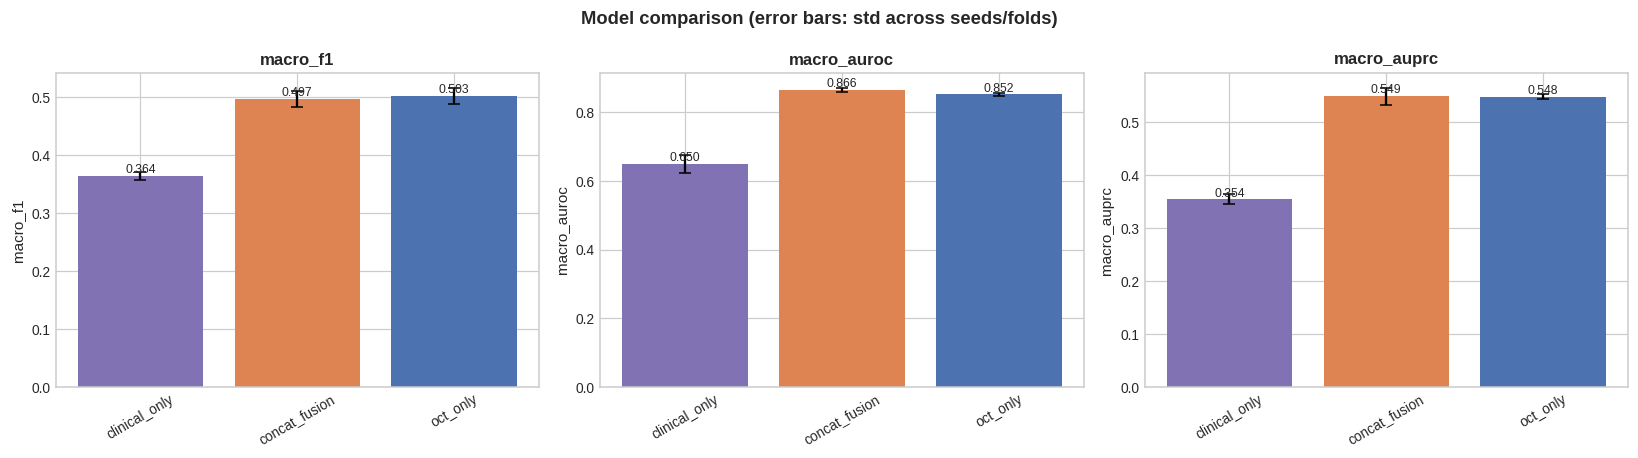

In [24]:
show(plotter.model_comparison(comparison), "01_model_comparison")

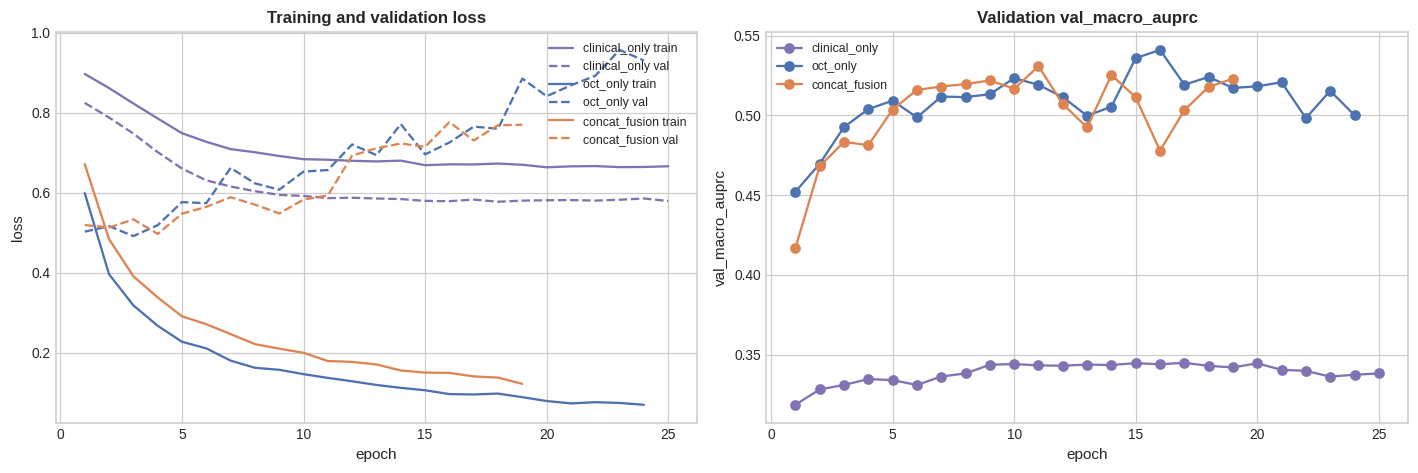

In [25]:
histories = {r.model_name: r.history.to_frame() for r in results if r.seed == SEEDS[0]}
show(plotter.training_curves(histories, monitor="val_macro_auprc"), "02_training_curves")

Watch for two failure modes in these curves:

- **Validation loss rising while training loss falls** — overfitting, expected with 52 training
  patients. Early stopping should catch it; check `epochs_run` above.
- **A flat monitored metric** — the model learned nothing, usually a learning-rate or
  class-weight problem rather than a capacity one.

In [26]:
if len(SEEDS) > 1:
    display(aggregator.across_seeds())
else:
    print("Single seed - no spread to report. Run several seeds before comparing models.")

,model,macro_f1_mean,macro_f1_std,macro_f1_count,macro_auroc_mean,macro_auroc_std,macro_auroc_count,macro_auprc_mean,macro_auprc_std,macro_auprc_count
0,clinical_only,0.3644,0.0063,3,0.6500,0.0262,3,0.3541,0.0096,3
1,concat_fusion,0.4971,0.0141,3,0.8660,0.0062,3,0.5492,0.0160,3
2,oct_only,0.5026,0.0143,3,0.8522,0.0033,3,0.5478,0.0045,3


---
## 6. Per-label results

The macro average hides the thing that matters most here: performance is bimodal, split between
the common biomarkers and the rare ones that barely appear in the test partition.

In [27]:
per_label = aggregator.per_label_pivot(metric="auprc")
per_label

model,n_positive,clinical_only,concat_fusion,oct_only
label,,,,
irhrf,973,0.8394,0.9408,0.9545
favf,873,0.5620,0.7883,0.8059
irf,711,0.7891,0.9690,0.9731
drt_me,514,0.7833,0.9613,0.9676
vitreous_debris,480,0.4575,0.7514,0.7337
pavf,278,0.2086,0.6289,0.6231
preretinal_tissue,145,0.4228,0.1990,0.2259
ez_disruption,60,0.0480,0.5172,0.4897
ir_hemorrhages,53,0.0734,0.1690,0.1552


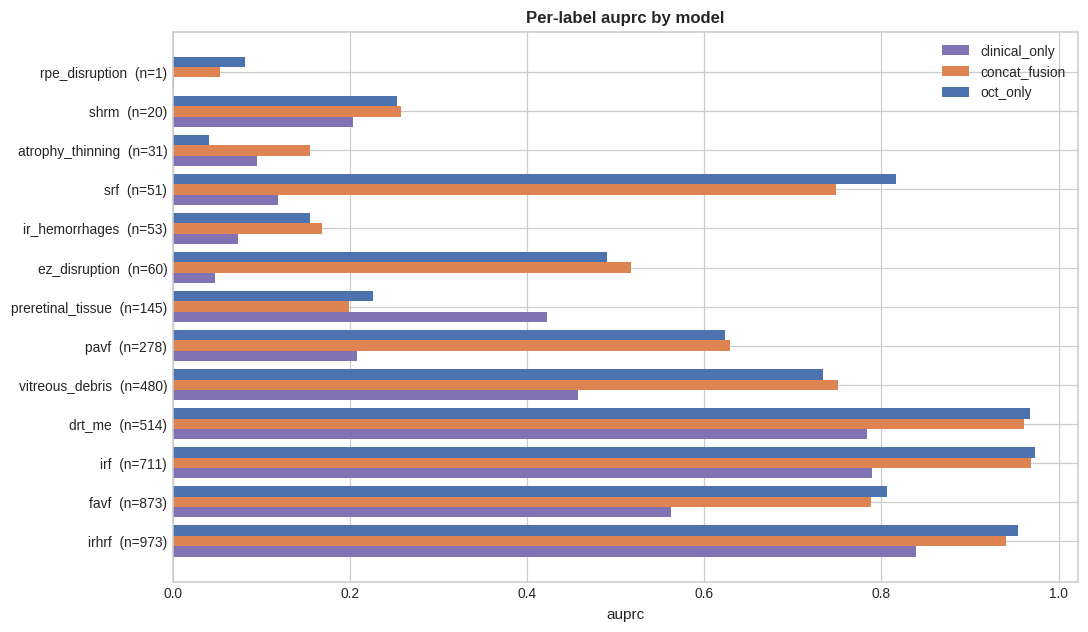

In [28]:
show(plotter.per_label_comparison(per_label, metric="auprc"), "03_per_label_auprc")

In [29]:
# Which labels could not be scored at all, and why.
undefined = aggregator.per_label()
undefined = undefined[undefined["degenerate"]][["run_id", "model", "label", "n_positive"]]
if len(undefined):
    display(undefined.drop_duplicates(["model", "label"]))
    print("\nThese labels have no positive examples in the test partition. Their metrics are "
          "undefined and are reported as NaN, never as 0.")
else:
    print("Every label had positives in the test partition.")

,run_id,model,label,n_positive
2,clinical_only_holdout_seed42,clinical_only,dril,0
9,clinical_only_holdout_seed42,clinical_only,vmt,0
14,clinical_only_holdout_seed42,clinical_only,ped_serous,0
18,oct_only_holdout_seed42,oct_only,dril,0
25,oct_only_holdout_seed42,oct_only,vmt,0
30,oct_only_holdout_seed42,oct_only,ped_serous,0
34,concat_fusion_holdout_seed42,concat_fusion,dril,0
41,concat_fusion_holdout_seed42,concat_fusion,vmt,0
46,concat_fusion_holdout_seed42,concat_fusion,ped_serous,0



These labels have no positive examples in the test partition. Their metrics are undefined and are reported as NaN, never as 0.


---
## 7. Reading the baselines

The three questions this phase exists to answer:

In [30]:
means = comparison.groupby("model")[["macro_f1", "macro_auroc", "macro_auprc"]].mean()
display(means.round(4))

clinical = means.loc["clinical_only"]
oct_only = means.loc["oct_only"]
concat = means.loc["concat_fusion"]

print("\n1. How much lives in BCVA + CST alone?")
print(f"   clinical-only macro AUROC = {clinical['macro_auroc']:.4f} "
      f"({'above' if clinical['macro_auroc'] > 0.55 else 'near'} chance)")

print("\n2. Does the image beat the clinical baseline?")
delta = oct_only["macro_auprc"] - clinical["macro_auprc"]
print(f"   OCT - clinical macro AUPRC = {delta:+.4f}")

print("\n3. Does plain concatenation add anything to the image?")
delta = concat["macro_auprc"] - oct_only["macro_auprc"]
print(f"   concat - OCT macro AUPRC   = {delta:+.4f}")
print("\n   A small or negative difference here does not close the question: it is exactly the")
print("   case gated fusion is meant to address, since concatenation cannot express an")
print("   interaction between the modalities.")

,macro_f1,macro_auroc,macro_auprc
model,,,
clinical_only,0.3644,0.6500,0.3541
concat_fusion,0.4971,0.8660,0.5492
oct_only,0.5026,0.8522,0.5478



1. How much lives in BCVA + CST alone?
   clinical-only macro AUROC = 0.6500 (above chance)

2. Does the image beat the clinical baseline?
   OCT - clinical macro AUPRC = +0.1937

3. Does plain concatenation add anything to the image?
   concat - OCT macro AUPRC   = +0.0014

   A small or negative difference here does not close the question: it is exactly the
   case gated fusion is meant to address, since concatenation cannot express an
   interaction between the modalities.


In [31]:
# Where does the clinical baseline do best? Compare against the EDA prediction that
# CST tracks the fluid biomarkers.
clinical_runs = [r for r in results if r.model_name == "clinical_only"]
if clinical_runs and clinical_runs[0].per_label is not None:
    table = clinical_runs[0].per_label[["label", "n_positive", "auroc", "auprc"]]
    display(table.sort_values("auroc", ascending=False).head(8))
    print("\nEDA predicted CST would separate the fluid biomarkers (irf, drt_me, srf) and be")
    print("uninformative about the vitreous-face ones (pavf, favf). Check that ordering above.")

,label,n_positive,auroc,auprc
15,shrm,20,0.8914,0.3321
10,drt_me,514,0.8623,0.7779
12,srf,51,0.8495,0.1205
7,preretinal_tissue,145,0.7849,0.4850
11,irf,711,0.7802,0.7963
3,ir_hemorrhages,53,0.6875,0.0776
4,irhrf,973,0.6832,0.8407
8,vitreous_debris,480,0.6312,0.5160



EDA predicted CST would separate the fluid biomarkers (irf, drt_me, srf) and be
uninformative about the vitreous-face ones (pavf, favf). Check that ordering above.


---
## 8. Findings and next step

**What is settled**

- The three baselines are trained on one fixed patient-grouped split, with thresholds fitted on
  validation and frozen before test.
- Per-label results show which biomarkers are measurable at all on this cohort.

**What is not settled**

- Whether any difference between models is real. That needs several seeds and the overlapping
  confidence intervals from Phase 5 — a gap in point estimates is not a result.
- Whether clinical features help *conditionally* on the image. Concatenation only tests one very
  restricted form of fusion.

**Next:** `03_gated_fusion.ipynb` — Model D, plus the ablations that tell us whether the gate is
doing anything at all.